In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [53]:
def format_pi_y_axis(ax):
    """
    Formats the y-axis of a Matplotlib Axes object to display ticks 
    in terms of pi/4, covering the range from 0 to 2*pi (approx 6.28).

    Args:
        ax (matplotlib.axes.Axes): The Axes object to format.
    """
    
    # Define the range end point
    max_value = 2 * np.pi
    
    # 1. Define the numerical locations for the ticks (every pi/4)
    # The step is np.pi / 4. We use a small epsilon (0.001) to ensure 2*pi is included.
    y_tick_values = np.arange(0, max_value + 0.001, np.pi / 4)

    # 2. Define the corresponding LaTeX formatted labels
    # 0, pi/4, pi/2, 3pi/4, pi, 5pi/4, 3pi/2, 7pi/4, 2pi (9 labels total)
    y_tick_labels = [
        '$0$', '$\pi/4$', '$\pi/2$', '$3\pi/4$', 
        '$\pi$', '$5\pi/4$', '$3\pi/2$', '$7\pi/4$', 
        '$2\pi$'
    ]
    
    # Safety check
    if len(y_tick_values) != len(y_tick_labels):
         print("Warning: Tick values and labels do not match length!")
         return
    
    # 3. Set the ticks, labels, and limits
    ax.set_yticks(y_tick_values)
    ax.set_yticklabels(y_tick_labels)
    ax.set_ylim(-0.1, max_value + 0.1) # Ensure the plot range is 0 to 2*pi

In [54]:
transistor = "BC547"
beta = 241 # Beta value
Vce = 4.98
Ic = 1.56
Q = (Vce, Ic) # Operation spot value

In [81]:
def plot_bode(df, save = False): 
    df_Hv = (df["V_out[V]"] - df["noise[V]"]) / df["V_in[V]"]
    df_phase = 2*np.pi*1E-6*df["lag[us]"]

    delta_in = 0.03*df["V_in[V]"] + 0.01*df["V_scale_in[V]"] + 0.001
    delta_out = 0.03*df["V_out[V]"] + 0.01*df["V_scale_out[V]"] + 0.001
    delta_noise = 0.03*df["noise[V]"] +  0.01*df["V_scale_out[V]"] + 0.001

    delta_df_Hv = delta_in*(df["V_out[V]"] - df["noise[V]"]) / (df["V_in[V]"]**2) + (delta_out+delta_noise)/ df["V_in[V]"]

    delta_f = 0.1
    delta_lag = df["t_scale[us]"]/250 + 50E-6*df["lag[us]"] + 6E-3

    df_HvdB = 20 * np.log10(df_Hv)
    df_HvdB_err = (20/np.log(10))*(delta_df_Hv/df_Hv)

    df_phi = df_phase*df["f_in[Hz]"]
    df_phi_err = 2*np.pi*1E-6*(df["lag[us]"]*delta_f+ df["f_in[Hz]"]*delta_lag)

    df_omega = 2*np.pi*df["f_in[Hz]"]
    df_omega_err = delta_f*df_omega/df["f_in[Hz]"]

    fig, (ax, bx) = plt.subplots(2,1,figsize=(8,10))
    ax.errorbar(df_omega, df_HvdB,xerr = df_omega_err, yerr = df_HvdB_err,fmt= '^' ,capsize=3, ecolor='k', color = 'r', ms = 5)
    ax.axvline(x=1e3, color='r', linestyle='--', linewidth=1)
    ax.axvline(x=5e6, color='r', linestyle='--', linewidth=1)
    ax.set(xlabel="$\omega$", ylabel="$H_{V,dB}$")

    bx.errorbar(df_omega,df_phi,xerr= df_omega_err, yerr = df_phi_err, fmt= '^' ,capsize=3, ecolor='k', color = 'b', ms = 5)
    bx.set(xlabel="$\omega$", ylabel="$\phi$")
    bx.axvline(x=1e3, color='b', linestyle='--', linewidth=1)
    bx.axvline(x=5e6, color='b', linestyle='--', linewidth=1)
    format_pi_y_axis(bx)

    ax.set_xscale('log'), bx.set_xscale('log')
    ax.grid(), bx.grid()

    ax.set_title("Gain"), bx.set_title("Phase")
    plt.suptitle(f"Bode diagram", fontweight='bold', fontsize=16,y=0.94)
    if save: plt.savefig(f"bode_diagram.png")
    #plt.tight_layout()
    plt.show()
    

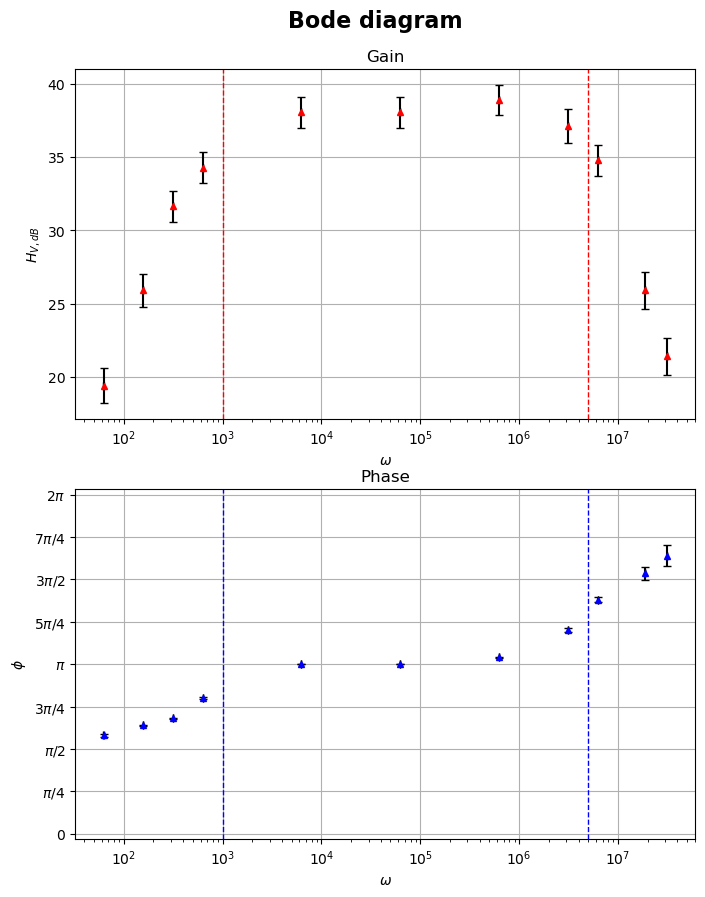

In [82]:
data_list  = "20251030_SINE.csv"
df = pd.read_csv(data_list) 
plot_bode(df, True)